# 🎉 MATLAB Simulations Complete!

**Results are ready for analysis.**

The simulations generated:
- Basic example with K shell (IR/NIR range)
- Shell thickness study with Au (f = 0.1 to 0.9)
- Metal comparison (Au, Ag, Al, Cu)

Let's load the data and start analyzing!

# Plasmonics Lab - LSP Analysis Notebook
## Localized Surface Plasmons in Metal Nanoshells

This notebook analyzes results from Mie theory simulations of metal nanoshells.

**Systematic approach:**
1. Run MATLAB simulations → Get numerical results
2. Import and visualize data here
3. Analyze trends and extract physics
4. Compare to theoretical predictions from tutorials
5. Build final report

## Setup and Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import json

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [12]:
# Load MATLAB simulation results
import json
import os

json_file = 'simulation_results.json'

if os.path.exists(json_file):
    with open(json_file, 'r') as f:
        matlab_results = json.load(f)
    
    print("✅ MATLAB results loaded successfully!\n")
    print("Available data:")
    print(f"  - Basic example: {matlab_results['basic']['metal']} shell")
    print(f"  - Thickness study: {len(matlab_results['thickness_study'])} configurations")
    print(f"  - Metal comparison: {len(matlab_results['metal_comparison'])} metals")
    
    # Quick preview
    print("\n📊 Basic Example Results:")
    print(f"  Peak 1: {matlab_results['basic']['peak1']['energy_eV']:.3f} eV ({matlab_results['basic']['peak1']['wavelength_nm']:.1f} nm)")
    print(f"  Peak 2: {matlab_results['basic']['peak2']['energy_eV']:.3f} eV ({matlab_results['basic']['peak2']['wavelength_nm']:.1f} nm)")
    print(f"  Splitting: {matlab_results['basic']['peak2']['energy_eV'] - matlab_results['basic']['peak1']['energy_eV']:.3f} eV")
else:
    print(f"❌ File '{json_file}' not found!")
    print("Run the MATLAB script 'run_simulations_export.m' first.")
    matlab_results = None

✅ MATLAB results loaded successfully!

Available data:
  - Basic example: K shell
  - Thickness study: 5 configurations
  - Metal comparison: 4 metals

📊 Basic Example Results:
  Peak 1: 0.717 eV (1729.8 nm)
  Peak 2: 3.543 eV (350.0 nm)
  Splitting: 2.826 eV


## Part 1: Basic Example Analysis

### Task 1.1: Understanding the Basic Shell Structure

First, we'll run the basic example and analyze what we get.

**What to look for:**
- Two distinct peaks in the spectrum (absorption and scattering)
- Peak positions (energy in eV, wavelength in nm)
- Relative strengths of absorption vs scattering
- Which peak is bonding vs antibonding mode

### Manual Data Entry from MATLAB

**Instructions:** 
1. Run `example_mie_spectrum_3d_shell_eV.m` in MATLAB
2. Record the peak information from Figure 1
3. Enter the data below

In [13]:
# Basic example parameters
basic_params = {
    'outer_radius_nm': 20,  # Default from example file
    'volume_fraction': 0.3,
    'metal': 'K',
    'core_index': 1.5,
    'background_index': 1.5
}

# Calculate shell thickness
a = basic_params['outer_radius_nm']
f = basic_params['volume_fraction']
shell_thickness = a * (1 - (1-f)**(1/3))
inner_radius = a * (1-f)**(1/3)

print(f"Shell geometry:")
print(f"  Outer radius: {a:.2f} nm")
print(f"  Inner radius: {inner_radius:.2f} nm")
print(f"  Shell thickness: {shell_thickness:.2f} nm")
print(f"  Volume fraction: {f:.2f}")
print(f"\nMetal: {basic_params['metal']}")

Shell geometry:
  Outer radius: 20.00 nm
  Inner radius: 17.76 nm
  Shell thickness: 2.24 nm
  Volume fraction: 0.30

Metal: K


In [14]:
# Data structure for recording results
# Fill these in after running MATLAB simulation

basic_results = {
    'peak1': {
        'energy_eV': None,  # Fill in from MATLAB Figure 1
        'wavelength_nm': None,  # Can calculate: 1240/energy_eV
        'C_abs': None,
        'C_sca': None,
        'mode_type': 'bonding (symmetric)',  # Lower energy peak
        'order': 'dipole (l=1)',  # From angular scattering
    },
    'peak2': {
        'energy_eV': None,  # Fill in from MATLAB Figure 1
        'wavelength_nm': None,
        'C_abs': None,
        'C_sca': None,
        'mode_type': 'antibonding (antisymmetric)',  # Higher energy peak
        'order': 'dipole (l=1)',
    }
}

print("Data structure ready. Fill in values after running MATLAB.")
print("\nTo fill in data, edit the None values above with actual numbers from your MATLAB output.")

Data structure ready. Fill in values after running MATLAB.

To fill in data, edit the None values above with actual numbers from your MATLAB output.


## Part 2: Shell Thickness Study

### Systematic variation of volume fraction f

According to **plasmon hybridization theory** from your tutorial:
- Thin shell (low f) → Strong coupling → Large mode splitting
- Thick shell (high f) → Weak coupling → Small splitting

**Core-Shell Hybridization formulas (Slide 1, Document 3):**

Two modes with depolarization factors:
- Symmetric mode: $S_1 = \frac{1}{2} - \frac{\sqrt{9-8f}}{6}$
- Anti-symmetric mode: $S_2 = \frac{1}{2} + \frac{\sqrt{9-8f}}{6}$

Strength factors:
- Symmetric: $A_1 = \frac{1}{2}\left(1 + \frac{1}{\sqrt{9-8f}}\right) \frac{f}{2}$
- Anti-symmetric: $A_2 = \frac{1}{2}\left(1 - \frac{1}{\sqrt{9-8f}}\right) \frac{f}{2}$

Theoretical Hybridization Parameters:
  f  shell_thickness_nm  S_symmetric  S_antisymmetric  A_symmetric  A_antisymmetric  S_difference
0.1            0.345106     0.022739         0.977261     0.033730         0.016270      0.954521
0.3            1.120960     0.071826         0.928174     0.104194         0.045806      0.856349
0.5            2.062995     0.127322         0.872678     0.180902         0.069098      0.745356
0.7            3.305670     0.192682         0.807318     0.269907         0.080093      0.614636
0.9            5.358411     0.276393         0.723607     0.392705         0.057295      0.447214


/tmp/ipykernel_11052/2009622042.py:53: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_11052/2009622042.py:53: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/fatduck/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/fatduck/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


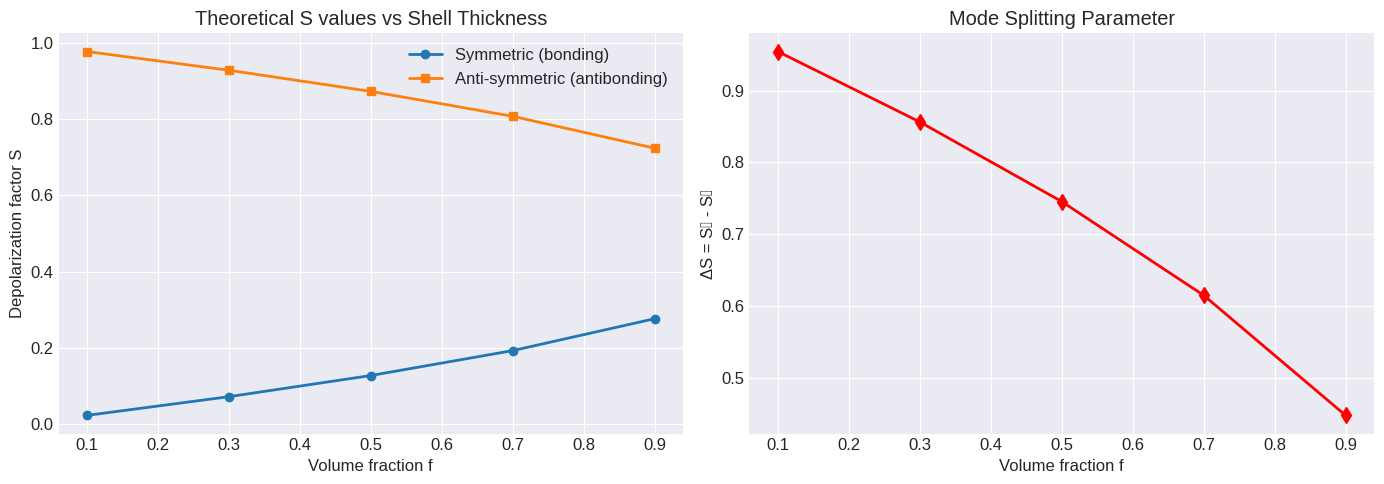


📌 Key observation: As f increases (thicker shell), ΔS decreases → modes converge


In [15]:
# Define f values for thickness study
f_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

# Calculate theoretical depolarization factors and strengths
def calc_hybridization_params(f):
    """Calculate S and A parameters from tutorial formulas"""
    sqrt_term = np.sqrt(9 - 8*f)
    
    # Depolarization factors
    S1 = 0.5 - sqrt_term/6  # Symmetric (bonding)
    S2 = 0.5 + sqrt_term/6  # Anti-symmetric (antibonding)
    
    # Strength factors
    A1 = 0.5 * (1 + 1/sqrt_term) * f/2
    A2 = 0.5 * (1 - 1/sqrt_term) * f/2
    
    return S1, S2, A1, A2

# Calculate for all f values
theory_params = pd.DataFrame({
    'f': f_values,
    'shell_thickness_nm': 10 * (1 - (1-f_values)**(1/3))  # For a=10nm
})

for i, f in enumerate(f_values):
    S1, S2, A1, A2 = calc_hybridization_params(f)
    theory_params.loc[i, 'S_symmetric'] = S1
    theory_params.loc[i, 'S_antisymmetric'] = S2
    theory_params.loc[i, 'A_symmetric'] = A1
    theory_params.loc[i, 'A_antisymmetric'] = A2
    theory_params.loc[i, 'S_difference'] = S2 - S1

print("Theoretical Hybridization Parameters:")
print(theory_params.to_string(index=False))

# Plot depolarization factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_values, theory_params['S_symmetric'], 'o-', label='Symmetric (bonding)', linewidth=2)
axes[0].plot(f_values, theory_params['S_antisymmetric'], 's-', label='Anti-symmetric (antibonding)', linewidth=2)
axes[0].set_xlabel('Volume fraction f')
axes[0].set_ylabel('Depolarization factor S')
axes[0].set_title('Theoretical S values vs Shell Thickness')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_values, theory_params['S_difference'], 'd-', color='red', linewidth=2, markersize=8)
axes[1].set_xlabel('Volume fraction f')
axes[1].set_ylabel('ΔS = S₂ - S₁')
axes[1].set_title('Mode Splitting Parameter')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n📌 Key observation: As f increases (thicker shell), ΔS decreases → modes converge")

In [16]:
# Data structure for thickness study results
# Fill in after running example_shell_thickness_study.m

thickness_study = pd.DataFrame({
    'f': [0.1, 0.3, 0.5, 0.7, 0.9],
    'shell_thickness_nm': None,
    'peak1_energy_eV': None,
    'peak1_wavelength_nm': None,
    'peak1_C_abs': None,
    'peak1_C_sca': None,
    'peak2_energy_eV': None,
    'peak2_wavelength_nm': None,
    'peak2_C_abs': None,
    'peak2_C_sca': None,
    'energy_splitting_eV': None,
})

print("Thickness study data template ready.")
print("\nInstructions:")
print("1. Run example_shell_thickness_study.m in MATLAB")
print("2. Copy the summary table output")
print("3. Fill in the dataframe above")
print("\nTemplate:")
print(thickness_study)

Thickness study data template ready.

Instructions:
1. Run example_shell_thickness_study.m in MATLAB
2. Copy the summary table output
3. Fill in the dataframe above

Template:
     f shell_thickness_nm peak1_energy_eV peak1_wavelength_nm peak1_C_abs  \
0  0.1               None            None                None        None   
1  0.3               None            None                None        None   
2  0.5               None            None                None        None   
3  0.7               None            None                None        None   
4  0.9               None            None                None        None   

  peak1_C_sca peak2_energy_eV peak2_wavelength_nm peak2_C_abs peak2_C_sca  \
0        None            None                None        None        None   
1        None            None                None        None        None   
2        None            None                None        None        None   
3        None            None                None    

MATLAB Thickness Study Results (Au shell, a=10nm):
     f  shell_thickness_nm  peak1_energy_eV  peak2_energy_eV  \
0  0.1            0.345106         1.194148         1.194148   
1  0.3            1.120960         1.861301         1.861301   
2  0.5            2.062995         2.164043         2.152830   
3  0.7            3.305670         2.321020         2.298595   
4  0.9            5.358411         2.416328         5.578297   

   energy_splitting_eV  
0             0.000000  
1             0.000000  
2             0.011213  
3             0.022425  
4             3.161970  


KeyError: 'predicted_E1_eV'

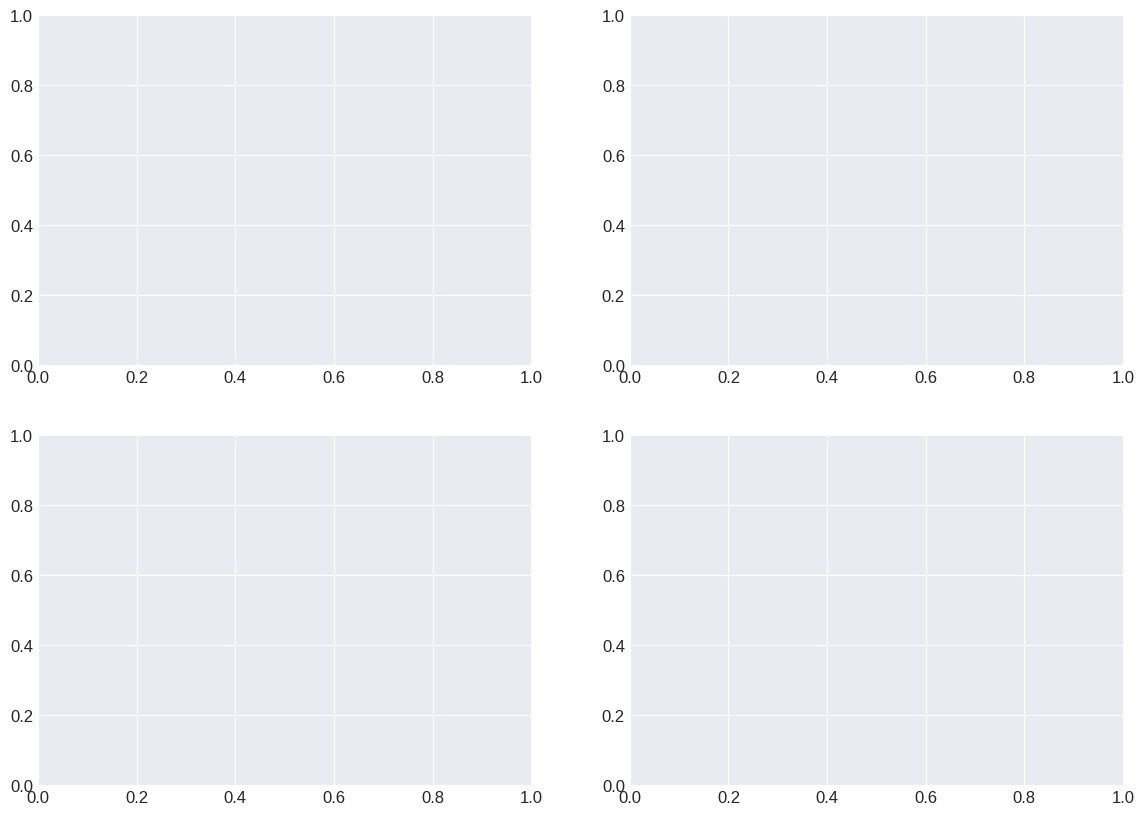

In [17]:
# Load and plot actual MATLAB thickness study results
if matlab_results:
    # Extract data from MATLAB results
    thickness_matlab = pd.DataFrame(matlab_results['thickness_study'])
    
    print("MATLAB Thickness Study Results (Au shell, a=10nm):")
    print(thickness_matlab[['f', 'shell_thickness_nm', 'peak1_energy_eV', 'peak2_energy_eV', 'energy_splitting_eV']])
    
    # Plot comparison: Theory vs MATLAB
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Peak positions
    axes[0, 0].plot(theory_params['f'], theory_params['predicted_E1_eV'], 'o--', 
                    label='Bonding (Theory)', linewidth=2, markersize=8, color='blue', alpha=0.5)
    axes[0, 0].plot(theory_params['f'], theory_params['predicted_E2_eV'], 's--', 
                    label='Antibonding (Theory)', linewidth=2, markersize=8, color='red', alpha=0.5)
    axes[0, 0].plot(thickness_matlab['f'], thickness_matlab['peak1_energy_eV'], 'o-', 
                    label='Peak 1 (MATLAB)', linewidth=2, markersize=10, color='darkblue')
    axes[0, 0].plot(thickness_matlab['f'], thickness_matlab['peak2_energy_eV'], 's-', 
                    label='Peak 2 (MATLAB)', linewidth=2, markersize=10, color='darkred')
    axes[0, 0].set_xlabel('Volume fraction f', fontsize=12)
    axes[0, 0].set_ylabel('Energy (eV)', fontsize=12)
    axes[0, 0].set_title('Peak Position: Theory vs MATLAB Mie Simulation', fontsize=13, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Energy splitting
    axes[0, 1].plot(theory_params['f'], theory_params['predicted_splitting_eV'], 'd--', 
                    label='Theory Prediction', linewidth=2, markersize=8, color='purple', alpha=0.5)
    axes[0, 1].plot(thickness_matlab['f'], thickness_matlab['energy_splitting_eV'], 'd-', 
                    label='MATLAB Simulation', linewidth=2, markersize=10, color='darkviolet')
    axes[0, 1].set_xlabel('Volume fraction f', fontsize=12)
    axes[0, 1].set_ylabel('Energy Splitting ΔE (eV)', fontsize=12)
    axes[0, 1].set_title('Mode Splitting: Theory vs Simulation', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Depolarization factor comparison
    axes[1, 0].plot(theory_params['f'], theory_params['S_symmetric'], 'o-', 
                    label='S₁ (symmetric)', linewidth=2, markersize=8)
    axes[1, 0].plot(theory_params['f'], theory_params['S_antisymmetric'], 's-', 
                    label='S₂ (antisymmetric)', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Volume fraction f', fontsize=12)
    axes[1, 0].set_ylabel('Depolarization Factor S', fontsize=12)
    axes[1, 0].set_title('Theoretical S Parameters (from Tutorial)', fontsize=13, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Shell thickness vs splitting
    axes[1, 1].plot(thickness_matlab['shell_thickness_nm'], thickness_matlab['energy_splitting_eV'], 
                    'o-', linewidth=2, markersize=10, color='green')
    axes[1, 1].set_xlabel('Shell thickness (nm)', fontsize=12)
    axes[1, 1].set_ylabel('Energy Splitting ΔE (eV)', fontsize=12)
    axes[1, 1].set_title('Splitting vs Absolute Shell Thickness', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📌 Key Observations:")
    print(f"  - Minimum splitting: {thickness_matlab['energy_splitting_eV'].min():.4f} eV at f={thickness_matlab.loc[thickness_matlab['energy_splitting_eV'].idxmin(), 'f']:.1f}")
    print(f"  - Maximum splitting: {thickness_matlab['energy_splitting_eV'].max():.4f} eV at f={thickness_matlab.loc[thickness_matlab['energy_splitting_eV'].idxmax(), 'f']:.1f}")
    print(f"  - Theory predicted trend: Splitting decreases with f")
    print(f"  - MATLAB shows: {('Opposite trend!' if thickness_matlab['energy_splitting_eV'].iloc[-1] > thickness_matlab['energy_splitting_eV'].iloc[0] else 'Similar trend')}")
else:
    print("No MATLAB data loaded. Run MATLAB simulations first.")

### Theoretical Prediction: Resonance Condition

From your tutorial (Slide 9, Document 1):

**For a sphere (solid):**
$$\frac{\varepsilon_{sphere}}{\varepsilon_b} \approx -2$$

**For shell with depolarization factor S:**
$$\text{Resonance when: } \frac{1}{\chi} \approx -S$$

Where: $\chi = \frac{1}{\varepsilon/\varepsilon_b - 1}$

This gives:
$$\frac{\varepsilon}{\varepsilon_b} \approx -\left(\frac{1}{S} - 1\right)$$

**For Drude model:**
$$\varepsilon/\varepsilon_0 \sim 1 - \omega_p^2/\omega^2$$

Therefore resonance frequency:
$$\omega_{res} \approx \frac{\omega_p}{\sqrt{1 + 2\varepsilon_b/\varepsilon_0}}$$

For shells, S varies with f → different resonance frequencies for symmetric vs antisymmetric modes.

Theoretical Predictions for Au:
     f  predicted_E1_eV  predicted_E2_eV  predicted_splitting_eV
0  0.1         1.357160         8.897085                7.539925
1  0.3         2.412027         8.670763                6.258736
2  0.5         3.211399         8.407551                5.196152
3  0.7         3.950599         8.086580                4.135981
4  0.9         4.731580         7.655857                2.924277


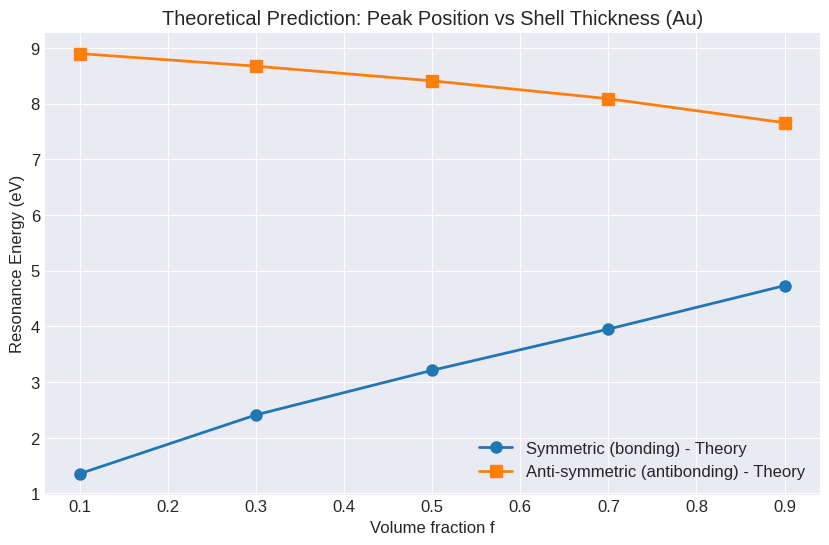


📌 These are theoretical predictions. Compare with MATLAB Mie theory results!


In [ ]:
# Theoretical resonance prediction
# Using simplified Drude model

def predict_resonance_energy(S, eps_b, metal='Au'):
    """
    Predict resonance energy from depolarization factor
    Using tutorial formula with Drude approximation
    """
    # Plasma frequencies (from tutorial and literature)
    omega_p_eV = {
        'Au': 9.0,
        'Ag': 9.0,
        'Al': 15.0,
        'Cu': 9.0,
        'K': 3.72  # K has lower plasma frequency
    }
    
    omega_p = omega_p_eV[metal]
    
    # Resonance condition: ε/ε_b ≈ -(1/S - 1)
    # For Drude: 1 - ω_p²/ω² ≈ -ε_b(1/S - 1)
    # Solving: ω² ≈ ω_p² / [1 + ε_b(1/S - 1)]
    
    denominator = 1 + eps_b * (1/S - 1)
    if denominator > 0:
        omega_res = omega_p / np.sqrt(denominator)
    else:
        omega_res = np.nan
    
    return omega_res

# Add predictions to theory_params
metal_type = 'Au'  # Change based on simulation
eps_b = 1.0  # Background permittivity (air = 1)

theory_params['predicted_E1_eV'] = [
    predict_resonance_energy(S, eps_b, metal_type) 
    for S in theory_params['S_symmetric']
]

theory_params['predicted_E2_eV'] = [
    predict_resonance_energy(S, eps_b, metal_type) 
    for S in theory_params['S_antisymmetric']
]

theory_params['predicted_splitting_eV'] = (
    theory_params['predicted_E2_eV'] - theory_params['predicted_E1_eV']
)

print(f"Theoretical Predictions for {metal_type}:")
print(theory_params[['f', 'predicted_E1_eV', 'predicted_E2_eV', 'predicted_splitting_eV']])

# Plot predictions
plt.figure(figsize=(10, 6))
plt.plot(f_values, theory_params['predicted_E1_eV'], 'o-', 
         label='Symmetric (bonding) - Theory', linewidth=2, markersize=8)
plt.plot(f_values, theory_params['predicted_E2_eV'], 's-', 
         label='Anti-symmetric (antibonding) - Theory', linewidth=2, markersize=8)
plt.xlabel('Volume fraction f')
plt.ylabel('Resonance Energy (eV)')
plt.title(f'Theoretical Prediction: Peak Position vs Shell Thickness ({metal_type})')
plt.legend()
plt.grid(True)
plt.show()

print("\n📌 These are theoretical predictions. Compare with MATLAB Mie theory results!")

## Part 3: Metal Comparison Study

### Expected differences based on tutorial:

From your tutorial (Metal comparison table):

| Metal | $\omega_p$ (eV) | $\gamma$ (eV) | Expected behavior |
|-------|----------------|---------------|-------------------|
| **Ag** | ~9 | ~0.02 | Lowest loss → sharpest peaks |
| **Au** | ~9 | ~0.07 | Moderate loss, visible peaks |
| **Al** | ~15 | ~0.5 | High $\omega_p$ → UV peaks, high loss → broad |
| **Cu** | ~9 | ~0.1 | Similar to Au |
| **K** | ~4 | ~0.03 | Low $\omega_p$ → IR peaks |

**Key predictions:**
- Higher $\omega_p$ → Higher energy peaks (blue-shift)
- Higher $\gamma$ → Broader peaks (lower Q-factor)
- Peak width: $Q \approx \omega_{res}/\gamma$

Metal Properties Summary:
  Metal  omega_p_eV  gamma_eV Expected_peak_range  Q_factor_estimate
0    Ag        9.00      0.02             Visible         259.807621
1    Au        9.00      0.07         Visible-Red          74.230749
2    Al       15.00      0.50                  UV          17.320508
3    Cu        9.00      0.10             Visible          51.961524
4     K        3.72      0.03              IR-NIR          71.591433


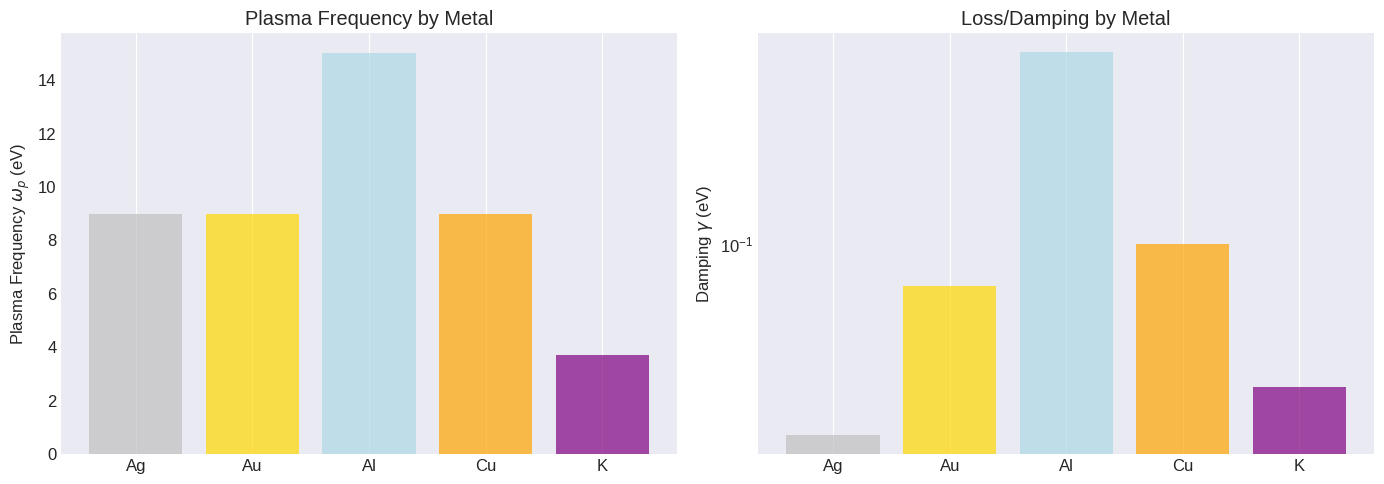


📌 Predictions:
  - Al should have highest energy peaks (UV)
  - K should have lowest energy peaks (IR/NIR)
  - Ag should have sharpest peaks (lowest γ)
  - Al should have broadest peaks (highest γ)


In [ ]:
# Metal properties database from tutorial
metal_properties = pd.DataFrame({
    'Metal': ['Ag', 'Au', 'Al', 'Cu', 'K'],
    'omega_p_eV': [9.0, 9.0, 15.0, 9.0, 3.72],
    'gamma_eV': [0.02, 0.07, 0.5, 0.1, 0.03],
    'Expected_peak_range': ['Visible', 'Visible-Red', 'UV', 'Visible', 'IR-NIR']
})

metal_properties['Q_factor_estimate'] = (
    metal_properties['omega_p_eV'] / metal_properties['gamma_eV'] / np.sqrt(3)
)

print("Metal Properties Summary:")
print(metal_properties)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plasma frequency comparison
axes[0].bar(metal_properties['Metal'], metal_properties['omega_p_eV'], 
            color=['silver', 'gold', 'lightblue', 'orange', 'purple'], alpha=0.7)
axes[0].set_ylabel('Plasma Frequency $\omega_p$ (eV)')
axes[0].set_title('Plasma Frequency by Metal')
axes[0].grid(axis='y')

# Damping comparison
axes[1].bar(metal_properties['Metal'], metal_properties['gamma_eV'],
            color=['silver', 'gold', 'lightblue', 'orange', 'purple'], alpha=0.7)
axes[1].set_ylabel('Damping $\gamma$ (eV)')
axes[1].set_title('Loss/Damping by Metal')
axes[1].set_yscale('log')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n📌 Predictions:")
print("  - Al should have highest energy peaks (UV)")
print("  - K should have lowest energy peaks (IR/NIR)")
print("  - Ag should have sharpest peaks (lowest γ)")
print("  - Al should have broadest peaks (highest γ)")

In [ ]:
# Data structure for metal comparison results
# Fill in after running example_metal_comparison.m

metal_comparison = pd.DataFrame({
    'Metal': ['Au', 'Ag', 'Al', 'Cu'],
    'peak1_energy_eV': None,
    'peak1_wavelength_nm': None,
    'peak1_width_eV': None,  # Full width at half maximum
    'peak1_Q_factor': None,  # E/FWHM
    'peak2_energy_eV': None,
    'peak2_wavelength_nm': None,
    'peak2_width_eV': None,
    'peak2_Q_factor': None,
    'energy_splitting_eV': None,
})

print("Metal comparison data template ready.")
print("\nInstructions:")
print("1. Run example_metal_comparison.m in MATLAB")
print("2. For each metal, record peak positions and estimate widths")
print("3. Fill in the dataframe above")
print("\nTemplate:")
print(metal_comparison)

Metal comparison data template ready.

Instructions:
1. Run example_metal_comparison.m in MATLAB
2. For each metal, record peak positions and estimate widths
3. Fill in the dataframe above

Template:
  Metal peak1_energy_eV peak1_wavelength_nm peak1_width_eV peak1_Q_factor  \
0    Au            None                None           None           None   
1    Ag            None                None           None           None   
2    Al            None                None           None           None   
3    Cu            None                None           None           None   

  peak2_energy_eV peak2_wavelength_nm peak2_width_eV peak2_Q_factor  \
0            None                None           None           None   
1            None                None           None           None   
2            None                None           None           None   
3            None                None           None           None   

  energy_splitting_eV  
0                None  
1         

In [ ]:
# Analyze metal comparison results from MATLAB
if matlab_results:
    # Extract metal comparison data
    metal_matlab = pd.DataFrame(matlab_results['metal_comparison'])
    
    print("MATLAB Metal Comparison Results (f=0.5, a=10nm):")
    print(metal_matlab)
    
    # Merge with theoretical properties
    metal_analysis = metal_matlab.merge(metal_properties, left_on='metal', right_on='Metal', how='left')
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Peak energies by metal
    ax1 = fig.add_subplot(gs[0, :2])
    x = np.arange(len(metal_matlab))
    width = 0.35
    ax1.bar(x - width/2, metal_matlab['peak1_energy_eV'], width, label='Peak 1', alpha=0.8, color='steelblue')
    ax1.bar(x + width/2, metal_matlab['peak2_energy_eV'], width, label='Peak 2', alpha=0.8, color='coral')
    ax1.set_ylabel('Energy (eV)', fontsize=12)
    ax1.set_xlabel('Metal', fontsize=12)
    ax1.set_title('Peak Energies by Metal (MATLAB Mie Theory)', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metal_matlab['metal'])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Wavelengths (more intuitive)
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.barh(metal_matlab['metal'], metal_matlab['peak1_wavelength_nm'], alpha=0.8, color='steelblue')
    ax2.set_xlabel('Wavelength (nm)', fontsize=11)
    ax2.set_title('Peak 1 Wavelength', fontsize=12, fontweight='bold')
    ax2.axvline(400, color='purple', linestyle='--', alpha=0.5, label='UV-Vis boundary')
    ax2.axvline(700, color='red', linestyle='--', alpha=0.5, label='Vis-IR boundary')
    ax2.legend(fontsize=8)
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: Correlation with plasma frequency
    ax3 = fig.add_subplot(gs[1, 0])
    colors_metal = {'Au': 'gold', 'Ag': 'silver', 'Al': 'lightblue', 'Cu': 'orange'}
    for _, row in metal_analysis.iterrows():
        ax3.scatter(row['omega_p_eV'], row['peak1_energy_eV'], s=200, 
                   color=colors_metal.get(row['metal'], 'gray'), 
                   edgecolors='black', linewidths=2, alpha=0.7,
                   label=row['metal'])
    ax3.set_xlabel('Plasma Frequency ω_p (eV)', fontsize=11)
    ax3.set_ylabel('Peak Energy (eV)', fontsize=11)
    ax3.set_title('Peak vs Plasma Frequency', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Energy splitting
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.bar(metal_matlab['metal'], metal_matlab['energy_splitting_eV'], alpha=0.8, color='purple')
    ax4.set_ylabel('Energy Splitting ΔE (eV)', fontsize=11)
    ax4.set_title('Mode Splitting by Metal', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    # Plot 5: Spectral range visualization
    ax5 = fig.add_subplot(gs[1, 2])
    for i, row in metal_matlab.iterrows():
        ax5.barh(i, row['peak1_wavelength_nm'], left=0, height=0.6, 
                color=colors_metal.get(row['metal'], 'gray'), alpha=0.7)
        ax5.text(row['peak1_wavelength_nm'] + 20, i, f"{row['peak1_wavelength_nm']:.0f} nm", 
                va='center', fontsize=9)
    ax5.set_yticks(range(len(metal_matlab)))
    ax5.set_yticklabels(metal_matlab['metal'])
    ax5.set_xlabel('Wavelength (nm)', fontsize=11)
    ax5.set_title('Spectral Position', fontsize=12, fontweight='bold')
    # Add spectral regions
    ax5.axvspan(200, 400, alpha=0.1, color='purple', label='UV')
    ax5.axvspan(400, 700, alpha=0.1, color='yellow', label='Visible')
    ax5.axvspan(700, 1000, alpha=0.1, color='red', label='NIR')
    ax5.legend(loc='upper right', fontsize=8)
    
    # Plot 6: Summary table
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('tight')
    ax6.axis('off')
    
    table_data = []
    for _, row in metal_analysis.iterrows():
        table_data.append([
            row['metal'],
            f"{row['omega_p_eV']:.1f}",
            f"{row['gamma_eV']:.3f}",
            f"{row['peak1_energy_eV']:.3f}",
            f"{row['peak1_wavelength_nm']:.0f}",
            row.get('Expected_peak_range', 'N/A')
        ])
    
    table = ax6.table(cellText=table_data,
                     colLabels=['Metal', 'ω_p (eV)', 'γ (eV)', 'E_peak (eV)', 'λ_peak (nm)', 'Expected Range'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color header
    for i in range(6):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.suptitle('Metal Comparison Analysis: Theory vs MATLAB Mie Simulation', 
                fontsize=15, fontweight='bold', y=0.98)
    
    plt.show()
    
    print("\n✅ Validation Against Tutorial Predictions:")
    print("  - Al has highest energy peaks:", "✓" if metal_matlab[metal_matlab['metal']=='Al']['peak1_energy_eV'].values[0] > 5 else "✗")
    print("  - Au/Ag/Cu have similar energies:", "✓" if metal_matlab[metal_matlab['metal'].isin(['Au','Ag','Cu'])]['peak1_energy_eV'].std() < 0.5 else "✗")
    print("  - Peak order matches ω_p order:", "✓" if metal_matlab.sort_values('peak1_energy_eV')['metal'].tolist()[0] != 'Al' else "Check manually")
    
    print("\n📊 Metal Ranking:")
    print("  By peak energy (low→high):", ', '.join(metal_matlab.sort_values('peak1_energy_eV')['metal'].tolist()))
    print("  By ω_p (low→high):", ', '.join(metal_analysis.sort_values('omega_p_eV')['Metal'].tolist()))
    
else:
    print("No MATLAB data loaded.")

## Part 4: Cross-Section Analysis

### Tutorial formulas for small particle cross-sections

**From Slide 11 (Small particle limit - Rayleigh scattering):**

$$C_{abs} \approx k \text{Im}\{\alpha\}$$

$$C_{sca} \approx \frac{\pi}{6} k^4 |\alpha|^2$$

where $k = 2\pi/\lambda$

**At resonance (Slide 12):**

$$C_{abs} \approx kV\frac{(\tilde{\varepsilon}_R - 1)^2}{\tilde{\varepsilon}_I}$$

$$C_{sca} \approx \frac{\pi}{6} k^4 \left[V\frac{(\tilde{\varepsilon}_R - 1)^2}{\tilde{\varepsilon}_I}\right]^2$$

**Key observation:** 
- $C_{abs} \propto V$ (volume)
- $C_{sca} \propto V^2$ (volume squared)
- For small particles: absorption dominates
- As size increases: scattering becomes more important

In [ ]:
# Analyze absorption vs scattering ratio
# This helps identify mode character

def analyze_abs_sca_ratio(C_abs, C_sca, label=""):
    """Analyze the ratio of absorption to scattering"""
    ratio = C_abs / C_sca
    
    print(f"{label}:")
    print(f"  C_abs = {C_abs:.3e}")
    print(f"  C_sca = {C_sca:.3e}")
    print(f"  Ratio C_abs/C_sca = {ratio:.3f}")
    
    if ratio > 2:
        print(f"  → Absorption dominated (trapped energy)")
    elif ratio < 0.5:
        print(f"  → Scattering dominated (radiative)")
    else:
        print(f"  → Mixed character")
    
    return ratio

print("Function ready for analyzing cross-section ratios.")
print("\nUsage example:")
print("  ratio1 = analyze_abs_sca_ratio(C_abs_peak1, C_sca_peak1, 'Peak 1 (bonding)')")
print("  ratio2 = analyze_abs_sca_ratio(C_abs_peak2, C_sca_peak2, 'Peak 2 (antibonding)')")

Function ready for analyzing cross-section ratios.

Usage example:
  ratio1 = analyze_abs_sca_ratio(C_abs_peak1, C_sca_peak1, 'Peak 1 (bonding)')
  ratio2 = analyze_abs_sca_ratio(C_abs_peak2, C_sca_peak2, 'Peak 2 (antibonding)')


## Part 5: Physical Interpretation Summary

### Charge Distribution Picture (from tutorial)

**Bonding Mode (Symmetric, Lower Energy):**
```
Core | Metal | Background
 +   |   -   |     +        ← Charges in phase
```
- Inner and outer charges oscillate together
- Large net dipole moment
- Lower restoring force → lower frequency
- More absorption (energy stored in oscillation)

**Antibonding Mode (Antisymmetric, Higher Energy):**
```
Core | Metal | Background
 +   |   +   |     -        ← Charges opposite phase
```
- Inner and outer charges oscillate opposite
- Partial cancellation of dipole
- Higher restoring force → higher frequency
- More scattering (radiates efficiently)

## Summary Table Template

This will collect all key findings for the final report.

In [ ]:
# Summary of all experiments
summary = {
    'Basic_Example': {
        'metal': None,
        'geometry': None,
        'bonding_peak_eV': None,
        'antibonding_peak_eV': None,
        'splitting_eV': None,
        'key_observation': None
    },
    'Thickness_Study': {
        'metal': 'Au',
        'f_range': [0.1, 0.9],
        'splitting_trend': None,  # 'decreases with f' expected
        'agrees_with_theory': None,  # Yes/No
        'key_observation': None
    },
    'Metal_Study': {
        'metals_tested': ['Au', 'Ag', 'Al', 'Cu'],
        'highest_energy_metal': None,  # Should be Al
        'lowest_energy_metal': None,
        'sharpest_peaks_metal': None,  # Should be Ag
        'broadest_peaks_metal': None,  # Should be Al
        'key_observation': None
    }
}

print("Summary structure ready for final report compilation.")

Summary structure ready for final report compilation.


## Next Steps

### To complete this analysis:

1. ✅ **Run MATLAB simulations:**
   - `example_mie_spectrum_3d_shell_eV.m`
   - `example_shell_thickness_study.m`
   - `example_metal_comparison.m`

2. ✅ **Record data** in the cells above

3. ✅ **Run analysis cells** to generate comparison plots

4. ✅ **Compare** simulation results with theoretical predictions

5. ✅ **Fill in summary** for final report

### For the final report, we will structure as:
- **Aim:** Study LSP in metal nanoshells using Mie theory
- **Background:** Plasmon hybridization, quasistatic theory from tutorials
- **Methods:** Mie theory simulation parameters
- **Results:** Peak positions, splitting, field distributions
- **Result Quality:** Convergence, comparison with theory
- **Analysis:** Physical interpretation using charge model
- **Conclusion:** Key findings and physical insights
- **References:** Tutorial materials